# NNTK Analysis: NTK vs. NNTK spectrum and finite-width convergence

In [16]:
import os

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from config import ExperimentConfig
from data import make_problem
from model import NN, flatten
from plotting import set_plot_style

torch.set_default_dtype(torch.float64)
device = torch.device("cpu")

set_plot_style()
os.makedirs("Figures/NNTK", exist_ok=True)

## Training data

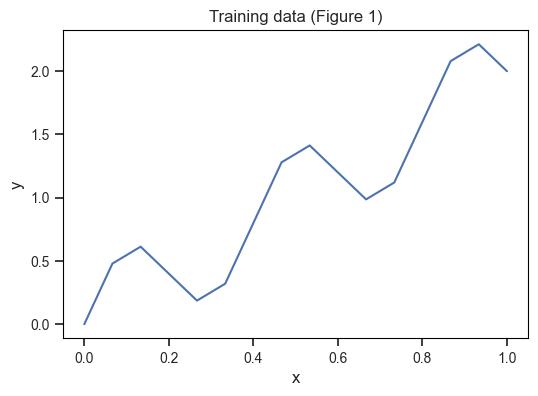

In [17]:
# Figure 1: y = 2x + 0.4 sin(5*pi*x)   (Remarks 5-6: eigenvalue spectrum / one-step convergence)
# Figure 2: y = 2x + 0.4 sin(20*pi*x)  (Lemma 9 / Theorem 7: finite-width convergence)
FIGURE = 1  # 1 or 2
frequency = 5 if FIGURE == 1 else 20

data_cfg = ExperimentConfig(
    n_points=16,
    linear_coef=2.0,
    freq0=frequency, amp0=0.4,
    amp1=0.0, amp2=0.0, amp3=0.0,
)

problem = make_problem(data_cfg, device, torch.float64)
x, y = problem["x"], problem["y"]
M = x.shape[0]

plt.figure(figsize=(6, 4))
plt.plot(x.cpu(), y.cpu())
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Training data (Figure {FIGURE})")
plt.show()

## NTK and NNTK Gram matrices

In [18]:
def compute_ntk(model, x):
    """Empirical standard NTK Gram matrix B = (1/M) J J^T, matching Eq. (15)."""
    y_pred = model(x)
    params = model.trainable_parameters()

    jac = []
    for i in range(x.size(0)):
        model.zero_grad()
        y_pred[i].backward(retain_graph=True)
        jac.append(flatten([p.grad for p in params]))
    J = torch.stack(jac)

    B = (J @ J.T) / x.size(0)
    return B, J


def newton_ntk(B, gamma):
    """Limit NNTK B*_0(gamma) = B (gamma*Id + B)^-1, matching Eq. (14)."""
    m = B.shape[0]
    return B @ torch.linalg.inv(gamma * torch.eye(m, dtype=B.dtype, device=B.device) + B)

## Experimental setting

In [19]:
beta = 0.52

In [20]:
# --- Sweep parameters ---
n_trials = 100

Ns = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
gammas = [10.0 ** k for k in range(-1, -11, -1)]

N_inf = 10**6  # proxy for the infinite-width limit
K = 1          # number of Newton steps
alpha = 1.0    # step size

## Sweep: finite-width NNTK vs. infinite-width limit

For each regularizer `gamma` and width `N`, computes the finite-width NNTK, takes one Newton
step, and compares against the infinite-width limit dynamics (Eq. 16-17) and limit NNTK (Eq. 14).

In [21]:
results_master = []
eigen_results = []

print(f"Computing the infinite-width standard NTK proxy (N={N_inf})...")
model_inf = NN(1, N_inf, 1, beta)
B_inf, _ = compute_ntk(model_inf, x)
B_inf = B_inf.detach()

std_eigenvalues = torch.linalg.eigvalsh(B_inf).cpu().numpy()[::-1]

I_M = torch.eye(M, dtype=torch.float64)


def format_gamma(gamma_val, prefix=""):
    exponent = int(np.floor(np.log10(float(gamma_val))))
    return rf"{prefix}$\gamma = 10^{{{exponent}}}$"


for gamma in gammas:
    g_label = format_gamma(gamma, prefix="NNTK with ")
    print(f"Processing gamma = {gamma} ({g_label})...")

    # Infinite-width regularizer, rescaled to match the normalization of B_inf
    gamma_inf = gamma * (N_inf ** (1 - 2 * beta))
    BB_inf = newton_ntk(B_inf, gamma_inf)

    newton_evals = torch.linalg.eigvalsh(BB_inf).cpu().numpy()[::-1]
    for i, val in enumerate(newton_evals):
        eigen_results.append({"Mode": i + 1, "Eigenvalue": val, "Gamma": gamma, "Gamma_Label": g_label})

    discrete_operators_inf = {t: torch.matrix_power(I_M - alpha * BB_inf, t) for t in range(1, K + 1)}

    for N in Ns:
        print(f"   Processing N = {N}...")
        gamma_N = gamma * (N ** (1 - 2 * beta))

        for trial_idx in range(n_trials):
            model = NN(1, N, 1, beta)

            with torch.no_grad():
                w0 = model.fc1.weight.data.detach().clone()
                b0 = model.fc1.bias.data.detach().clone()
                a0 = model.fc2.weight.data.detach().clone()

            f0 = model(x).detach().clone()
            f_current = f0.clone()
            max_z_norm_across_time = 0.0

            for t in range(1, K + 1):
                B_t, _ = compute_ntk(model, x)
                BB_t = newton_ntk(B_t, gamma_N)

                with torch.no_grad():
                    update = BB_t @ (y - f_current)
                    f_current = f_current + alpha * update

                with torch.no_grad():
                    nntk_diff = torch.norm(BB_t - BB_inf, p="fro").item()
                    nntk_ref = torch.norm(BB_inf, p="fro").item()
                    kernel_error = nntk_diff / nntk_ref

                # Newton step in weight space: solve (gamma*Id + B_t) coeffs = (y - f)/M,
                # then backprop the pseudo-loss sum(f_pred * coeffs) to obtain z_t = J^T coeffs.
                params = model.trainable_parameters()
                y_pred = model(x)
                model.zero_grad()

                inv_term = torch.linalg.inv(gamma_N * I_M + B_t)
                newton_coeffs = (inv_term @ (y - y_pred.detach())) / M

                loss_pseudo = torch.sum(y_pred * newton_coeffs)
                loss_pseudo.backward()

                with torch.no_grad():
                    for p in params:
                        p.data += alpha * p.grad
                        p.grad.zero_()

                with torch.no_grad():
                    wt, bt, at = model.fc1.weight.data, model.fc1.bias.data, model.fc2.weight.data
                    dw_sq = (wt - w0).pow(2).sum(dim=1)
                    db_sq = (bt - b0).pow(2)
                    da_sq = (at - a0).pow(2).sum(dim=0)
                    z_i_norms = torch.sqrt(dw_sq + db_sq + da_sq)
                    current_step_max = torch.max(z_i_norms).item()
                    max_z_norm_across_time = max(max_z_norm_across_time, current_step_max)

                f_t_star = y - discrete_operators_inf[t] @ (y - f0)

                results_master.append({
                    "width $N$": N,
                    "Gamma": gamma,
                    "Gamma_Label": format_gamma(gamma),
                    "time $t$": t,
                    "conv_error": torch.norm(f_current - f_t_star).item() / torch.norm(f_t_star).item(),
                    "target_error": torch.norm(f_current - y).item() / torch.norm(y).item(),
                    "target_error_inf": torch.norm(f_t_star - y).item() / torch.norm(y).item(),
                    "kernel_error": kernel_error,
                    "gamma_kernel_error": gamma * kernel_error,
                    "max_z_norm": max_z_norm_across_time,
                    "gamma_max_z_norm": gamma * max_z_norm_across_time,
                    "trial": trial_idx,
                })

df_master = pd.DataFrame(results_master)
df_eigen = pd.DataFrame(eigen_results)
df_std = pd.DataFrame({"Mode": range(1, len(std_eigenvalues) + 1), "Eigenvalue": std_eigenvalues})

Computing the infinite-width standard NTK proxy (N=1000000)...
Processing gamma = 0.1 (NNTK with $\gamma = 10^{-1}$)...
   Processing N = 10...
   Processing N = 20...
   Processing N = 50...
   Processing N = 100...
   Processing N = 200...
   Processing N = 500...
   Processing N = 1000...
   Processing N = 2000...
   Processing N = 5000...
   Processing N = 10000...
   Processing N = 20000...
   Processing N = 50000...
   Processing N = 100000...
   Processing N = 200000...
   Processing N = 500000...
   Processing N = 1000000...
Processing gamma = 0.01 (NNTK with $\gamma = 10^{-2}$)...
   Processing N = 10...
   Processing N = 20...
   Processing N = 50...
   Processing N = 100...
   Processing N = 200...
   Processing N = 500...
   Processing N = 1000...
   Processing N = 2000...
   Processing N = 5000...
   Processing N = 10000...
   Processing N = 20000...
   Processing N = 50000...
   Processing N = 100000...
   Processing N = 200000...
   Processing N = 500000...
   Processing

## Plot styling & label helpers

In [22]:
sorted_gammas = sorted(df_master["Gamma"].unique(), reverse=True)

ordered_labels = [format_gamma(g) for g in sorted_gammas]
nntk_ordered_labels = [format_gamma(g, prefix="NNTK with ") for g in sorted_gammas]

viridis_cmap = plt.get_cmap("viridis")
colors = [viridis_cmap(i) for i in np.linspace(0.2, 0.8, len(sorted_gammas))]
custom_palette = dict(zip(ordered_labels, colors))
nntk_palette = dict(zip(nntk_ordered_labels, colors))


def trim(group, col, low=0.10, high=0.90):
    """Drop the outer quantile tails of ``col`` within a group for a cleaner plot."""
    lo, hi = group[col].quantile(low), group[col].quantile(high)
    return group[(group[col] >= lo) & (group[col] <= hi)]

## Figure 1a -- eigenvalue spectrum (Remark 5)

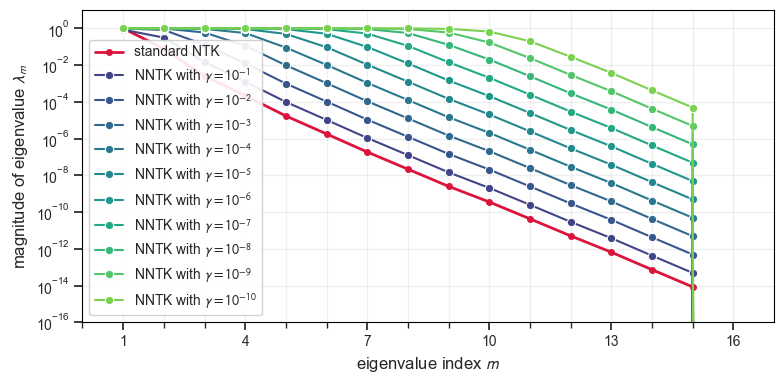

In [23]:
plt.figure(figsize=(8, 4))

std_eig_norm = std_eigenvalues / np.max(std_eigenvalues)
plt.plot(
    range(1, len(std_eig_norm) + 1), std_eig_norm,
    label=r"standard NTK",
    color="crimson", linestyle="-", marker="o", markersize=4, linewidth=2, zorder=1,
)

ax = sns.lineplot(
    data=df_eigen, x="Mode", y="Eigenvalue", hue="Gamma_Label",
    hue_order=nntk_ordered_labels, palette=nntk_palette, marker="o",
)

ax.set_yscale("log")
ax.set_ylabel(r"magnitude of eigenvalue $\lambda_m$", fontsize=12)
ax.set_xlabel(r"eigenvalue index $m$", fontsize=12)
ax.set_xlim(0, M + 1)
ax.set_xticks(range(1, M + 1, 3))
ax.set_xticks(range(0, M + 1, 1), minor=True)
ax.set_ylim(1e-16, 10)
ax.grid(True, which="both", alpha=0.3)

plt.legend(loc="lower left", frameon=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig("Figures/NNTK/Figure1a_Eigenvalue_Spectrum.pdf", bbox_inches="tight")
plt.show()

## Figure 1b -- one-step loss vs. width (Remark 6)

/var/folders/gn/30sbcq3d6pd3mng3dj2g53y80000gn/T/ipykernel_98334/4242720905.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot = df_step1.groupby(["width $N$", "Gamma_Label"], group_keys=False).apply(


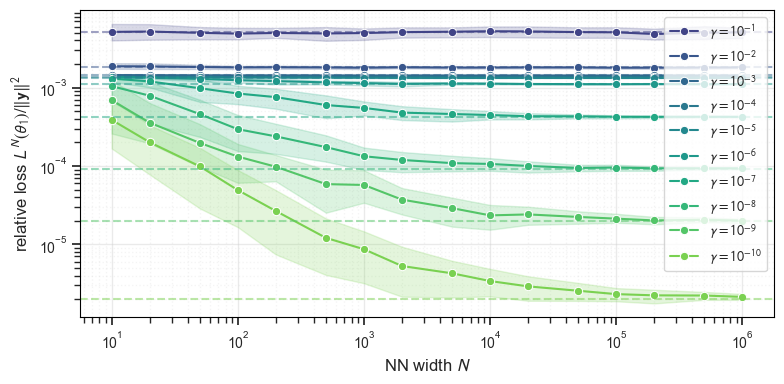

In [24]:
df_step1 = df_master[df_master["time $t$"] == 1].copy()
df_step1["relative_loss"] = df_step1["target_error"] ** 2 / (2 * M)
df_step1["relative_loss_inf"] = df_step1["target_error_inf"] ** 2 / (2 * M)

df_plot = df_step1.groupby(["width $N$", "Gamma_Label"], group_keys=False).apply(
    lambda g: trim(g, "relative_loss")
)

plt.figure(figsize=(8, 4))
ax = sns.lineplot(
    data=df_plot, x="width $N$", y="relative_loss", hue="Gamma_Label",
    hue_order=ordered_labels, palette=custom_palette, marker="o", markersize=6, errorbar=("pi", 80),
)

for g_label in ordered_labels:
    theory_val = df_step1.loc[df_step1["Gamma_Label"] == g_label, "relative_loss_inf"].mean()
    plt.axhline(y=theory_val, color=custom_palette[g_label], linestyle="--", alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"relative loss $L^N(\theta_1)/\|\mathbf{y}\|^2$", fontsize=12)
ax.set_xlabel(r"NN width $N$", fontsize=12)
ax.grid(True, which="major", alpha=0.4, linestyle="-")
ax.grid(True, which="minor", alpha=0.2, linestyle=":")

plt.legend(loc="upper right", frameon=True, framealpha=0.8, fontsize=10)
plt.tight_layout()
plt.savefig("Figures/NNTK/Figure1b_OneStep_Loss.pdf", bbox_inches="tight")
plt.show()

## Figure 2a -- norm of Newton updates (Lemma 9)

/var/folders/gn/30sbcq3d6pd3mng3dj2g53y80000gn/T/ipykernel_98334/3754721202.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot_z = df_z.groupby(["width $N$", "Gamma_Label"], group_keys=False).apply(


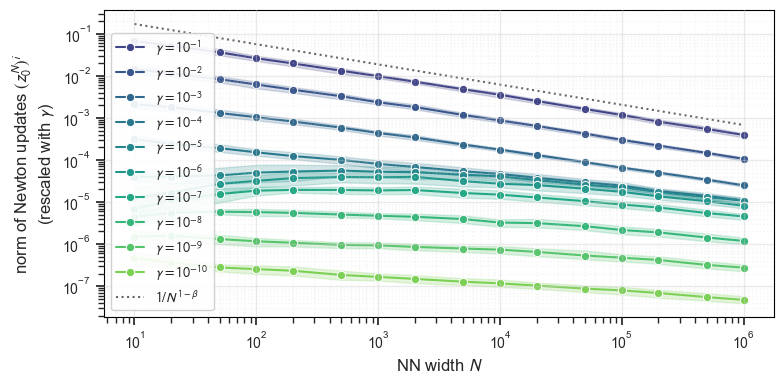

In [25]:
df_z = df_master[df_master["time $t$"] == K].copy()
df_plot_z = df_z.groupby(["width $N$", "Gamma_Label"], group_keys=False).apply(
    lambda g: trim(g, "gamma_max_z_norm")
)

plt.figure(figsize=(8, 4))
ax = sns.lineplot(
    data=df_plot_z, x="width $N$", y="gamma_max_z_norm", hue="Gamma_Label",
    hue_order=ordered_labels, palette=custom_palette, marker="o", errorbar=("pi", 80),
)

if beta < 1:
    N_range = np.array(Ns)
    ref_val = df_plot_z.loc[df_plot_z["width $N$"] == Ns[0], "gamma_max_z_norm"].max()
    reference_line = 2 * ref_val * (Ns[0] / N_range) ** (1 - beta)
    ax.plot(N_range, reference_line, color="black", linestyle=":", alpha=0.6,
            label=r"$1/N^{1-\beta}$", zorder=1)
    ax.set_axisbelow(False)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"norm of Newton updates $(z_0^N)^i$" + "\n" + r"(rescaled with $\gamma$)", fontsize=12)
ax.set_xlabel(r"NN width $N$", fontsize=12)
ax.grid(True, which="major", alpha=0.4, linestyle="-")
ax.grid(True, which="minor", alpha=0.2, linestyle=":")

plt.legend(loc="lower left", frameon=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig("Figures/NNTK/Figure2a_Newton_Update_Norm.pdf", bbox_inches="tight")
plt.show()

## Figure 2b -- NNTK convergence to the infinite-width limit (Theorem 7)

/var/folders/gn/30sbcq3d6pd3mng3dj2g53y80000gn/T/ipykernel_98334/1052358345.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot_kernel = df_kernel.groupby(["width $N$", "Gamma_Label"], group_keys=False).apply(


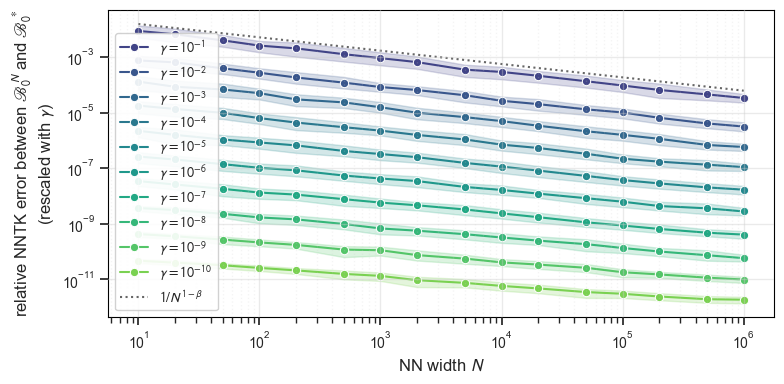

In [26]:
df_kernel = df_master[df_master["time $t$"] == K].copy()
df_plot_kernel = df_kernel.groupby(["width $N$", "Gamma_Label"], group_keys=False).apply(
    lambda g: trim(g, "gamma_kernel_error")
)

plt.figure(figsize=(8, 4))
ax = sns.lineplot(
    data=df_plot_kernel, x="width $N$", y="gamma_kernel_error", hue="Gamma_Label",
    hue_order=ordered_labels, palette=custom_palette, marker="o", errorbar=("pi", 80),
)

if beta < 1:
    N_range = np.array(Ns)
    ref_val = df_plot_kernel.loc[df_plot_kernel["width $N$"] == Ns[0], "gamma_kernel_error"].max()
    reference_line = ref_val * (Ns[0] / N_range) ** (1 - beta)
    ax.plot(N_range, reference_line, color="black", linestyle=":", alpha=0.6,
            label=r"$1/N^{1-\beta}$", zorder=1)
    ax.set_axisbelow(False)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(
    r"relative NNTK error between $\mathscr{B}_0^N$ and $\mathscr{B}_0^*$" + "\n" + r"(rescaled with $\gamma$)",
    fontsize=12,
)
ax.set_xlabel(r"NN width $N$", fontsize=12)
ax.grid(True, which="major", alpha=0.4, linestyle="-")
ax.grid(True, which="minor", alpha=0.2, linestyle=":")

plt.legend(loc="lower left", frameon=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig("Figures/NNTK/Figure2b_NNTK_Convergence.pdf", bbox_inches="tight")
plt.show()